In [1]:
import os
import sys
import yaml
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

proj_root = f'{os.environ["HOME"]}/gitlab/timer'
sys.path.append(proj_root)

setting default: fixed = []
setting default: fit_basis = duration
setting default: chromatic = False
setting default: include_mean = True
setting default: include_flare = False
setting default: include_bump = False
setting default: use_gp = False
setting default: chains = 2
setting default for m2g: add_bias = False
setting default for m2r: add_bias = False
setting default for m2i: add_bias = False
setting default for m2z: add_bias = False
setting default for m2g: quadratic = False
setting default for m2r: quadratic = False
setting default for m2i: quadratic = False
setting default for m2z: quadratic = False
setting default for m2g: trim_beg = None
setting default for m2r: trim_beg = None
setting default for m2i: trim_beg = None
setting default for m2z: trim_beg = None
setting default for m2g: trim_end = None
setting default for m2r: trim_end = None
setting default for m2i: trim_end = None
setting default for m2z: trim_end = None
setting default for m2g: clip = False
setting default for

Output()

Initial log probability: -16574.33
Final log probability: -16574.33
Log probability improvement: 0.00
Optimization improvement below threshold. Attempting sequential optimization.


Output()

Output()

Output()

Output()

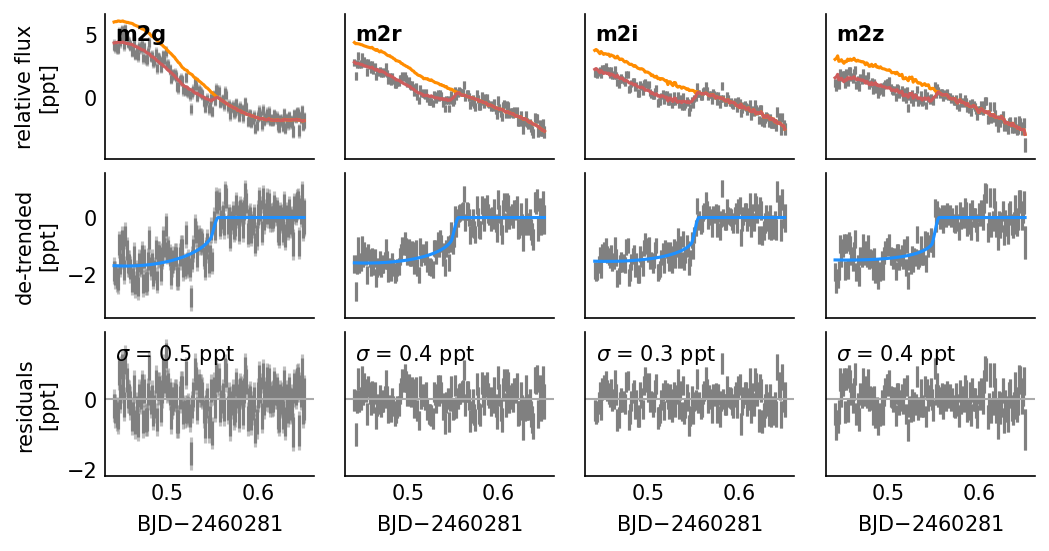

In [2]:
from timer.fit import TransitFit

wd = os.path.join(proj_root, 'examples/v1298tau-m2')
fp = f'{wd}/fit.yaml'
fit_params = yaml.load(open(fp), Loader=yaml.FullLoader)
fp = f'{wd}/sys.yaml'
sys_params = yaml.load(open(fp), Loader=yaml.FullLoader)
fit_params['clobber'] = True
fit_params['cores'] = 2
fit_params['tune'] = 500
fit_params['draws'] = 500

fit = TransitFit(sys_params, fit_params, wd=wd)
fit.build_model()

sampling for 500 tuning steps and 500 draws with 2 chains on 2 cores


Initializing NUTS using adapt_full...
/opt/homebrew/Caskroom/miniconda/base/envs/timerpymc/lib/python3.13/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [u_star_z, u_star_r, u_star_g, u_star_i, dur, t0, period, ror, b, m2g_mean, m2g_weights, m2g_log_sigma_lc, m2r_mean, m2r_weights, m2r_log_sigma_lc, m2i_mean, m2i_weights, m2i_log_sigma_lc, m2z_mean, m2z_weights, m2z_log_sigma_lc]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 120 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


r_hat max: 1.04
Max. log probability after sampling: -546.67
m2g residual scatter: 3190 ppm
m2r residual scatter: 2092 ppm
m2i residual scatter: 1683 ppm
m2z residual scatter: 1734 ppm


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
t0[0],0.454,0.002,0.450,0.457,0.000,0.000,1399.0,875.0,1.00
period[0],8.249,0.000,8.249,8.249,0.000,0.000,1657.0,752.0,1.00
b[0],0.204,0.159,-0.091,0.473,0.007,0.005,540.0,586.0,1.00
dur[0],0.204,0.003,0.198,0.210,0.000,0.000,1887.0,887.0,1.00
ror[0],0.039,0.001,0.036,0.041,0.000,0.000,872.0,816.0,1.00
m2g_log_sigma_lc,-1.091,0.120,-1.325,-0.881,0.003,0.003,1366.0,817.0,1.00
m2r_log_sigma_lc,-3.810,2.671,-9.232,-1.265,0.195,0.106,224.0,395.0,1.01
m2i_log_sigma_lc,-3.243,2.327,-8.529,-1.331,0.248,0.131,105.0,296.0,1.04
m2z_log_sigma_lc,-3.548,2.534,-8.907,-1.298,0.142,0.083,373.0,603.0,1.01


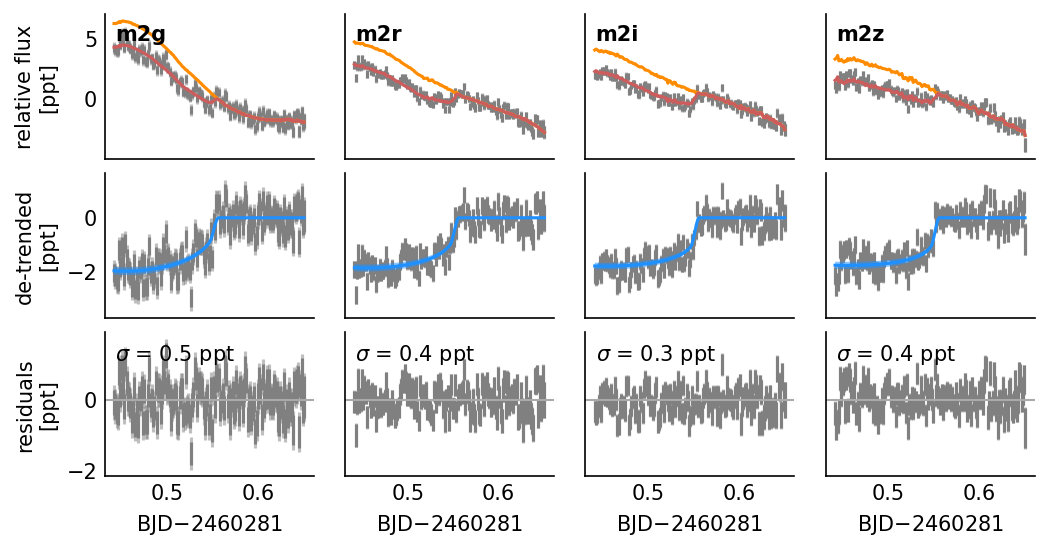

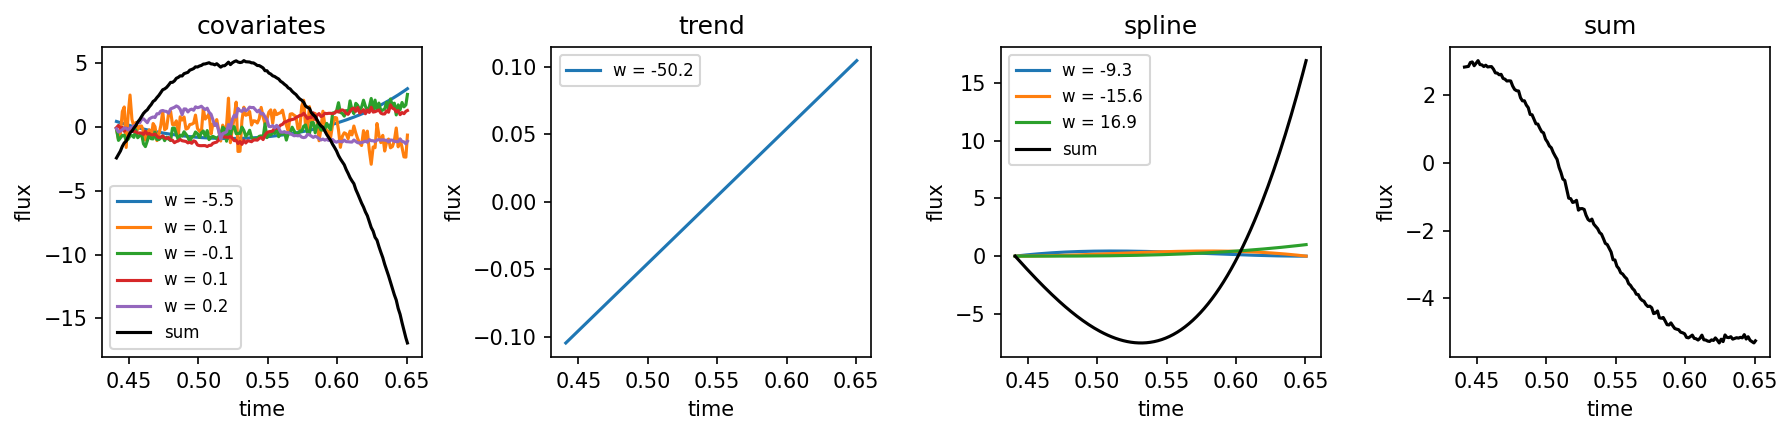

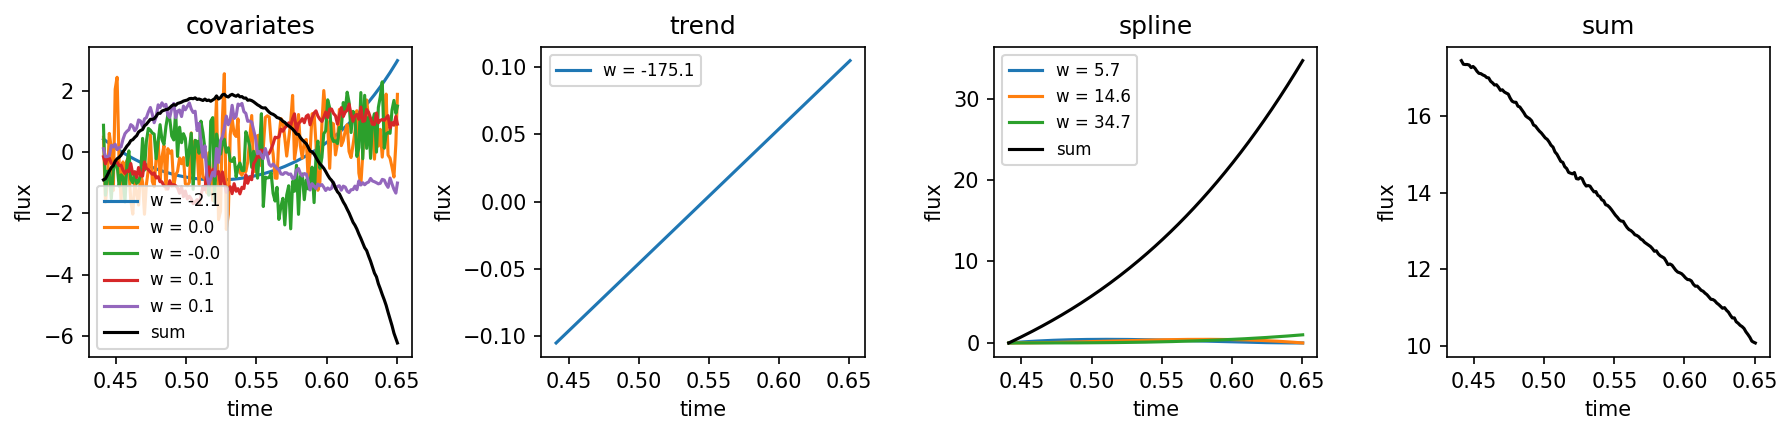

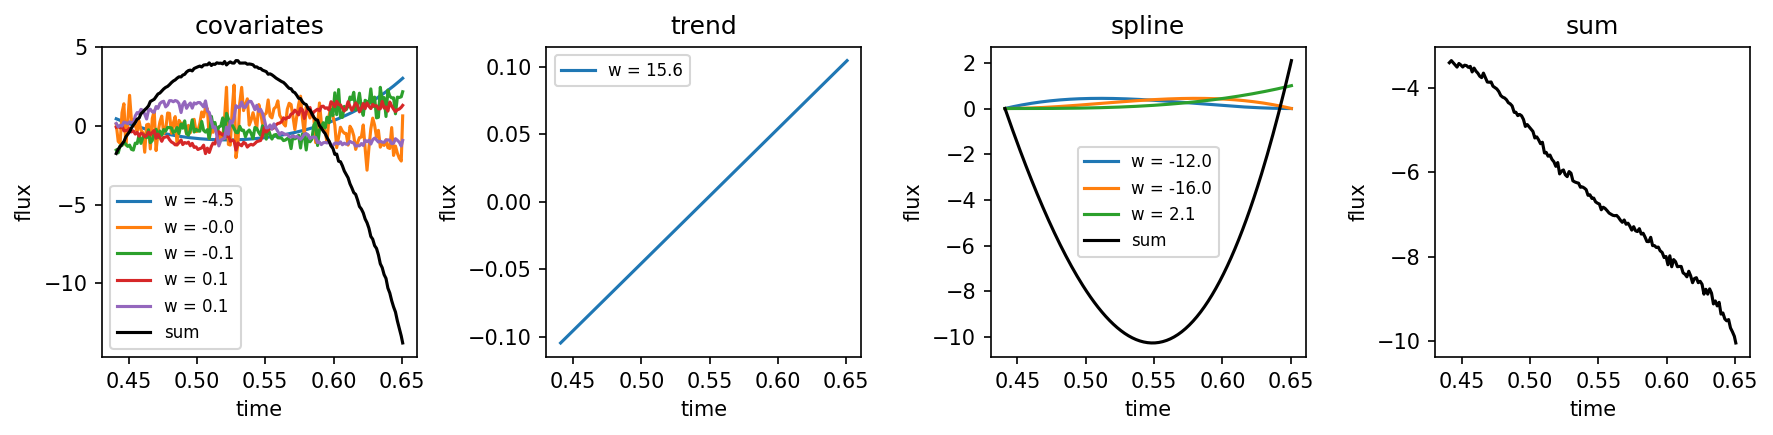

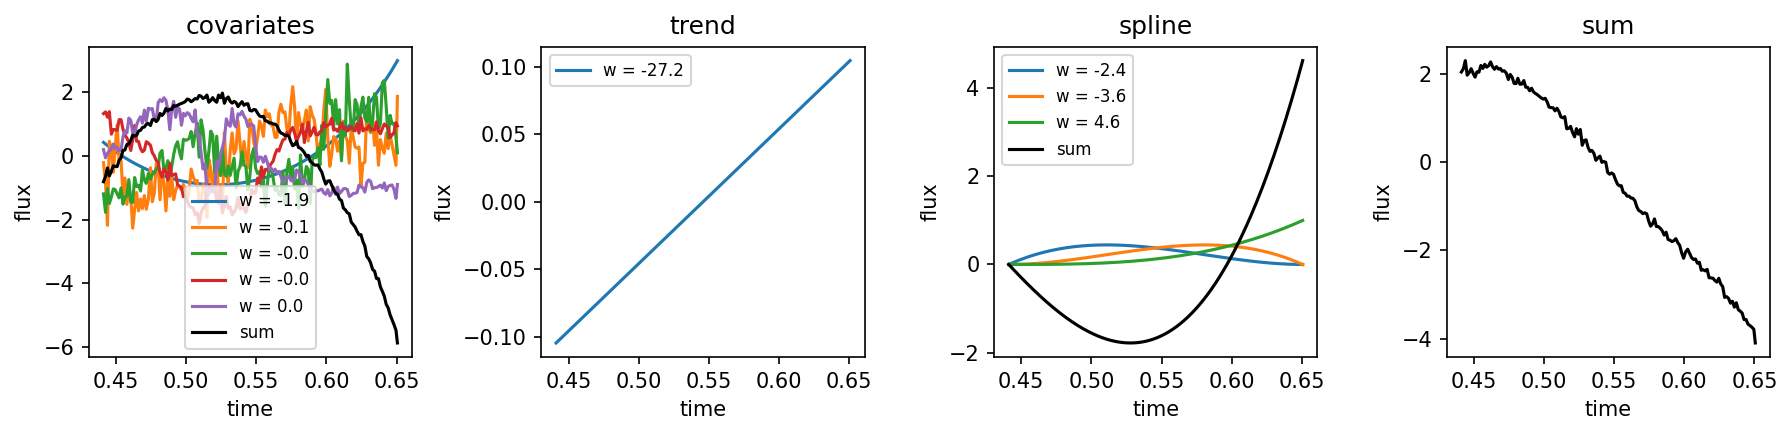

In [3]:
fit.sample()
fit.summary

generating trace plot


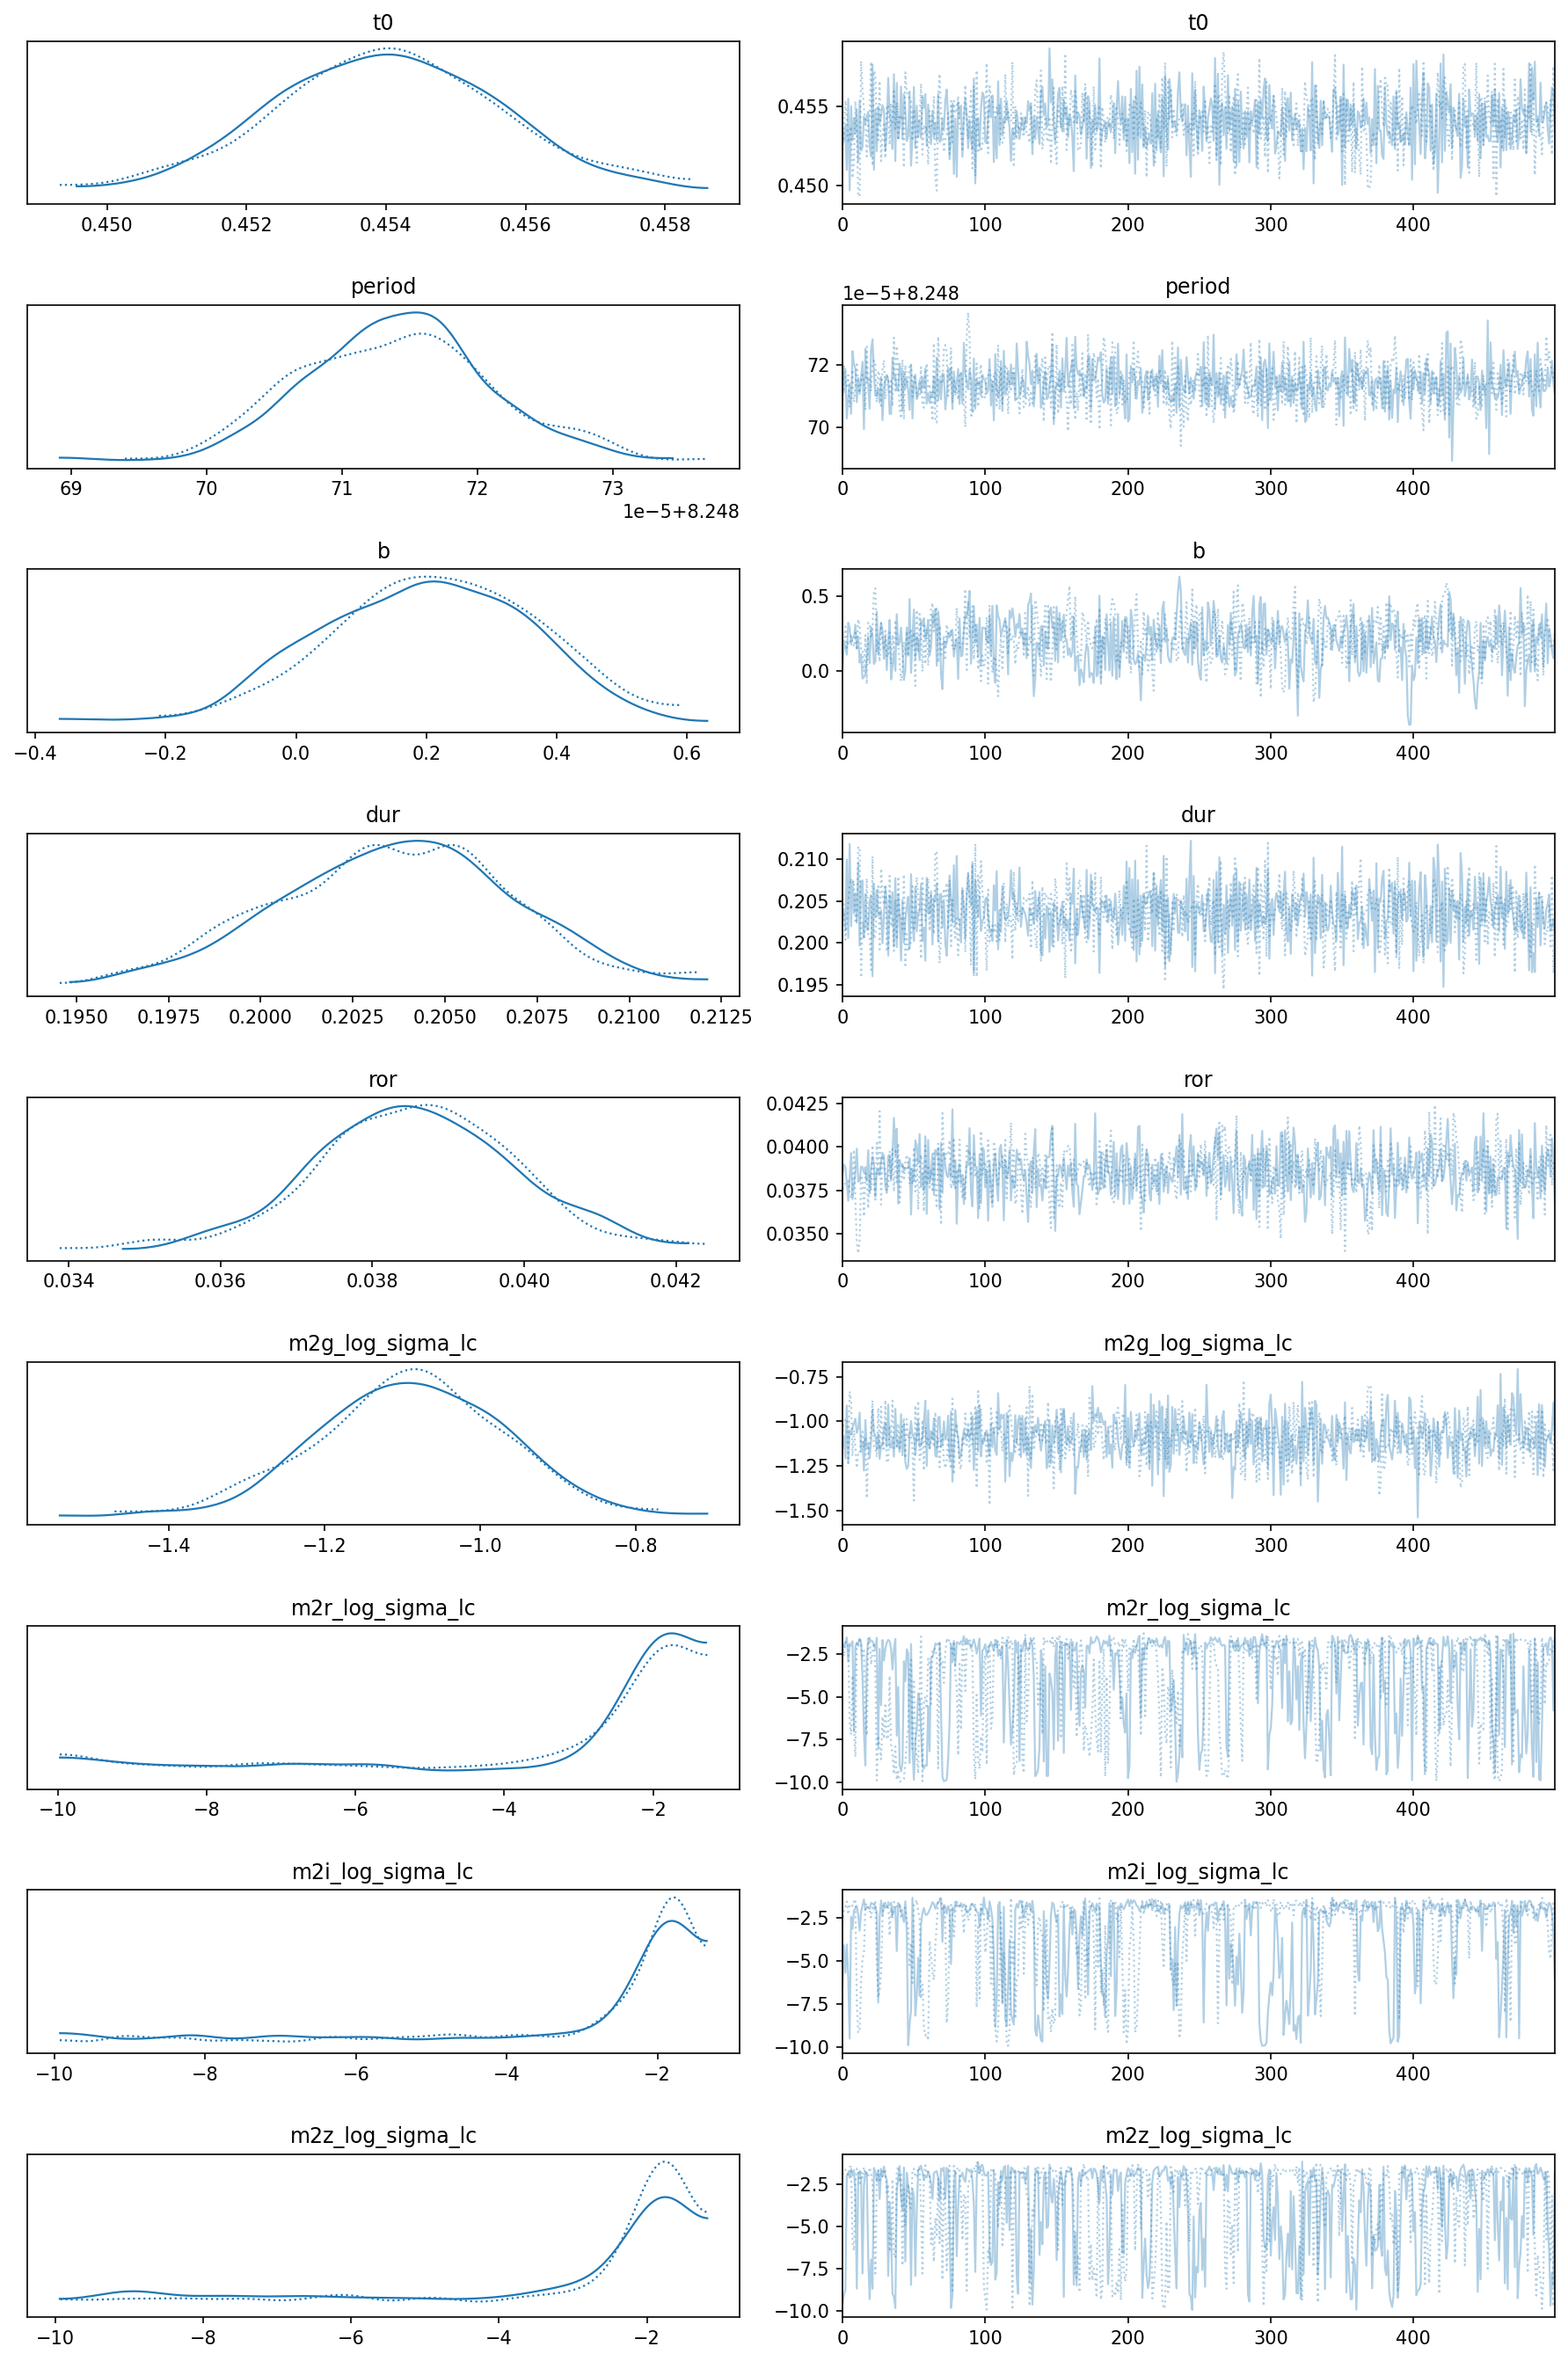

In [5]:
fit.plot_trace()

generating corner plot


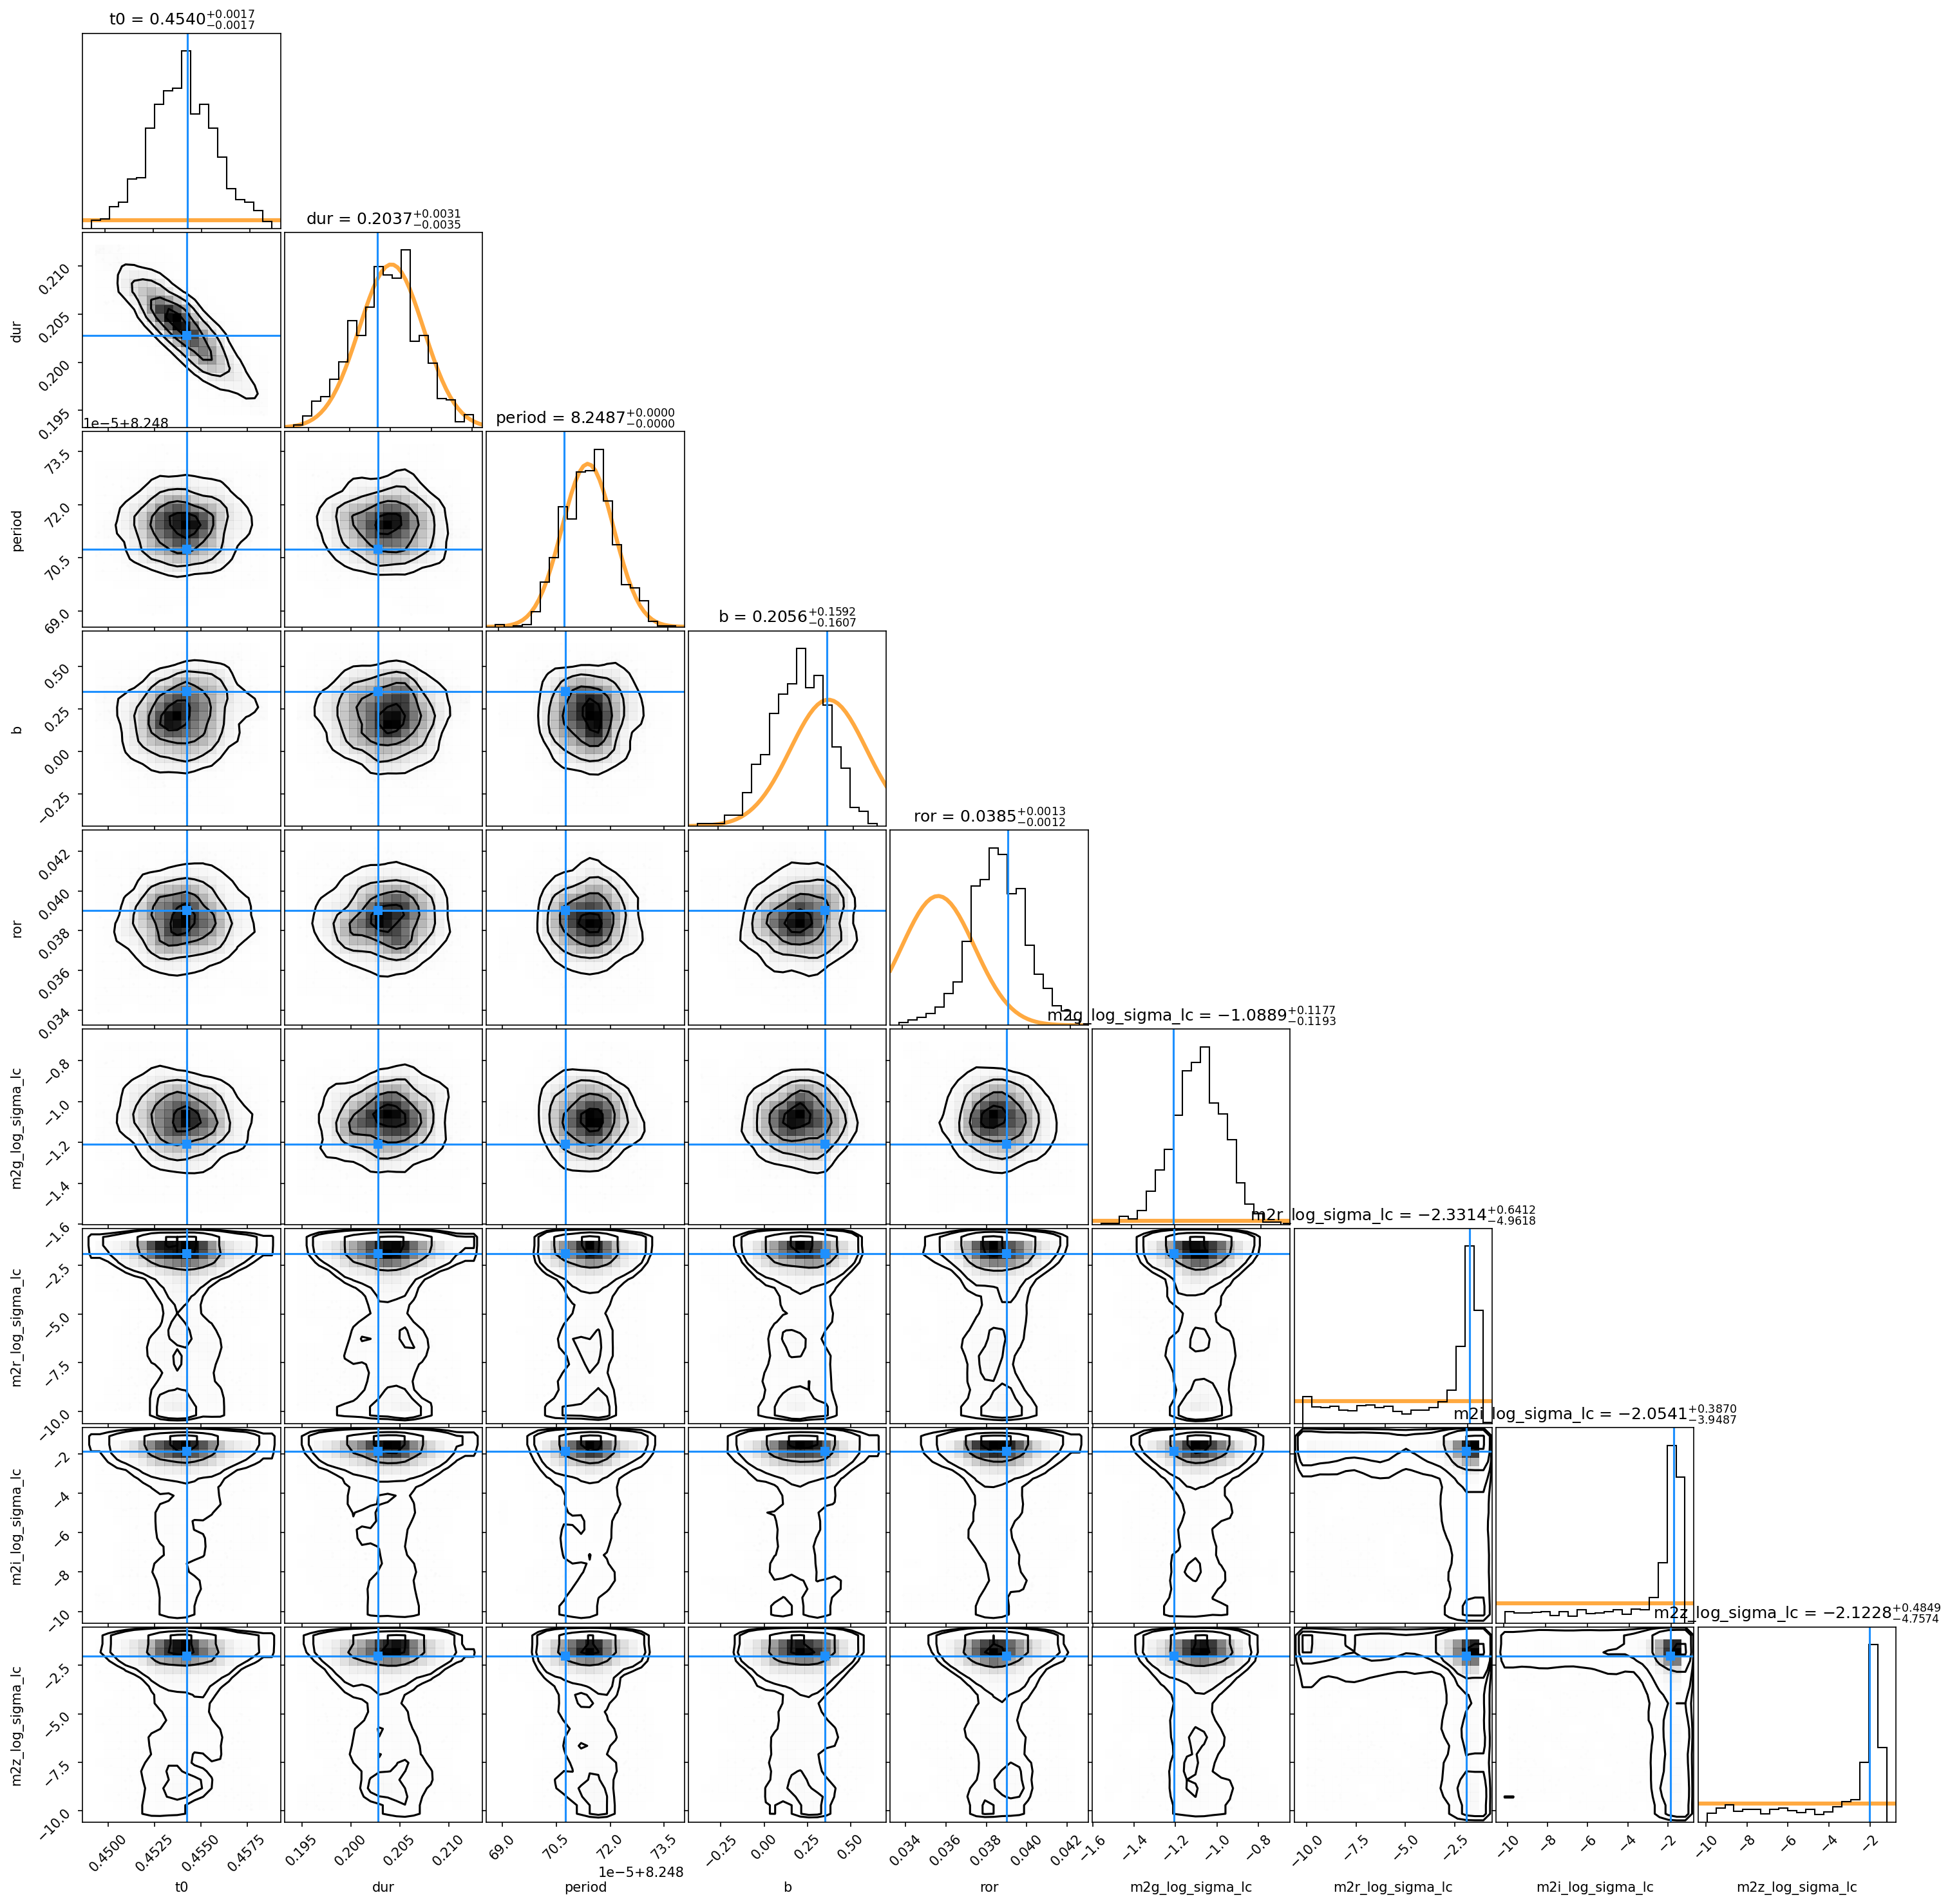

In [6]:
fit.plot_corner()

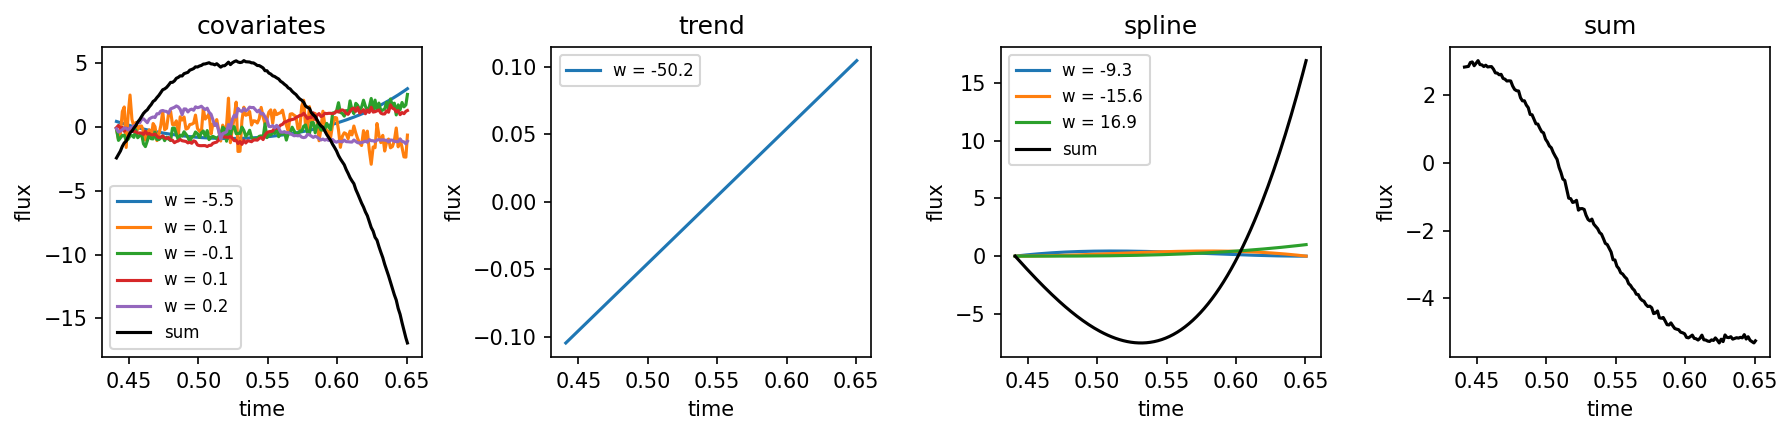

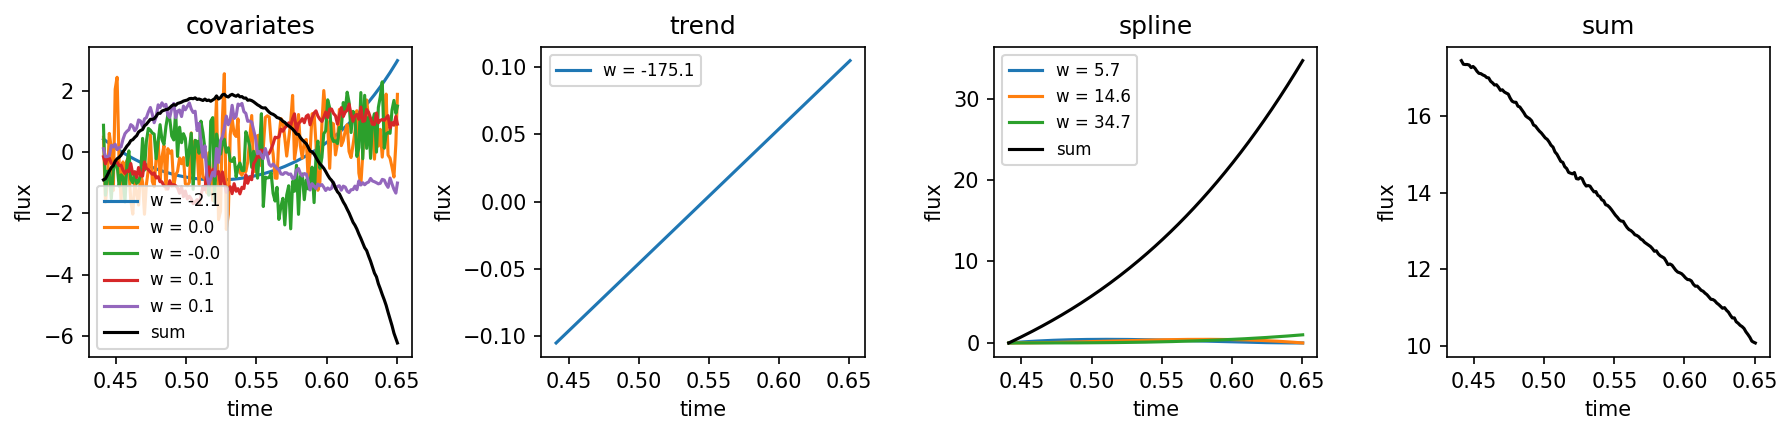

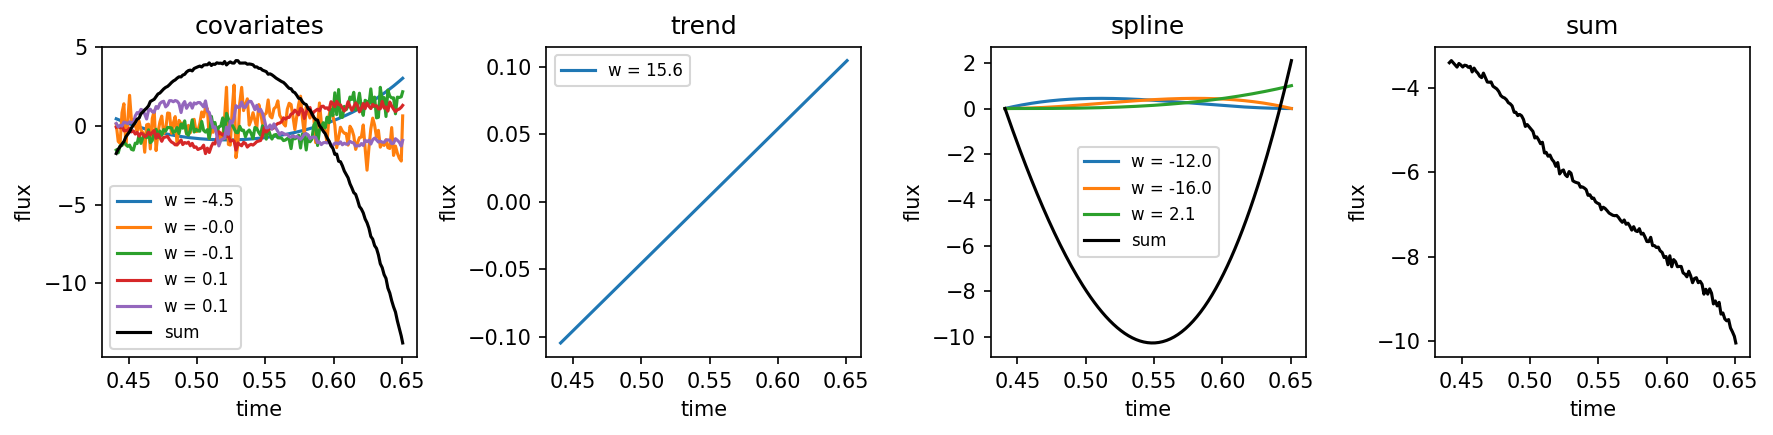

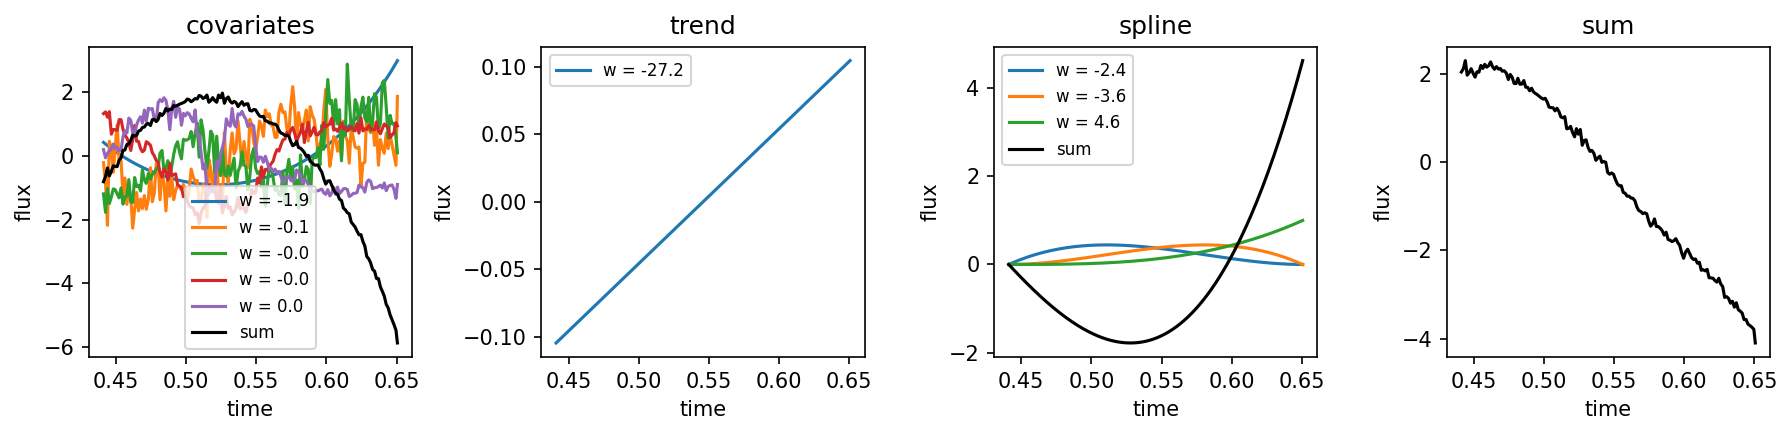

In [7]:
for name in fit.data.keys():
    fit.plot_systematics(name, style=2)